# BD2 -- Sesión 5 -- Cassandra

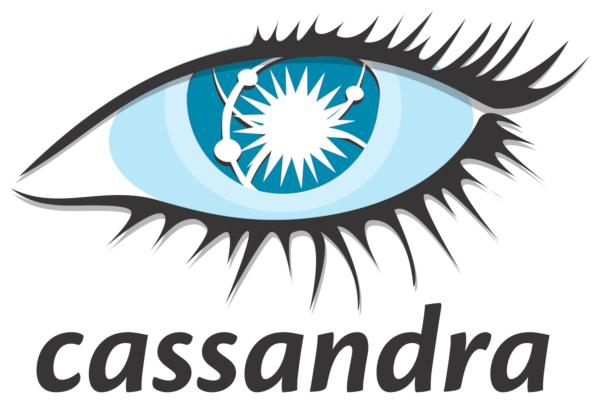

**Objetivos**
- Entender la arquitectura y el modelo de datos de Apache Cassandra.
- Aprender a arrancar un nodo Cassandra y conectarse desde Python.
- Diseñar tablas enfocadas a consultas concretas y ejecutar operaciones básicas con CQL y el driver.
- Conocer replicación, consistencia, TTL, tombstones y mantenimiento básico.

Con Cassandra vamos a simular un modo semi-clúster con una sola máquina.

In [1]:
import sys

RunningInCOLAB: bool = "google.colab" in sys.modules

In [2]:
# Aparentemente han eliminado java de los paquetes instalados
if RunningInCOLAB:
    !sudo apt-get update && sudo apt-get install -y default-jdk-headless  --no-install-recommends

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,803 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,943 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,305 kB]
Get

In [3]:
if RunningInCOLAB:
    # Search for the first java interpreter. This code should work. If not, adjust JAVA_HOME manually.
    import os
    from pathlib import Path

    def find_java_home() -> str | None:
        p = Path("/usr/lib/jvm")
        (_, dirs, _) = next(os.walk(p))
        for d in dirs:
            inner_java: Path = p / d / "bin" / "java"
            if inner_java.is_file() and inner_java.stat().st_mode & 0o111:
                return str(p.joinpath(d).absolute())
        return None

    JAVA_HOME: str | None = os.getenv("JAVA_HOME", find_java_home())
    %env JAVA_HOME=$JAVA_HOME

env: JAVA_HOME=/usr/lib/jvm/java-1.17.0-openjdk-amd64


## Instalación de Apache Cassandra (sólo Google Colab)

Descargamos el ejecutable comprimido desde su página oficial. Sólo si estamos en Colab.

In [4]:
if RunningInCOLAB:
    # Determinar qué versión 5.x.x de Cassandra es la más reciente.
    import re
    from re import Pattern
    from urllib.request import Request, urlopen

    from bs4 import BeautifulSoup

    version_re: Pattern = re.compile(r"^(5\.[0-9]+(\.[0-9]+)?)")
    req = Request("https://dlcdn.apache.org/cassandra/")
    html_page = urlopen(req)

    soup = BeautifulSoup(html_page)
    bigger5x: str = max(
        *[
            m.group(0)
            for m in [version_re.match(link.get_text()) for link in soup.find_all("a")]
            if m
        ],
        "5.0.0",
    )  # Base version 5.x.x
    %env CASSANDRA_VER=$bigger5x

env: CASSANDRA_VER=5.0.7


Descarga de Cassandra y de su firma digital SHA256 para comprobar que el fichero es correcto. Si es correcto, se descomprime. Esto sólo se realiza en Google Colab.

In [5]:
if RunningInCOLAB:
    import hashlib
    import os
    import tarfile
    import urllib.request
    from typing import cast

    # Descargar Cassandra y su firma digital SHA256
    cassandra_version: str = os.getenv("CASSANDRA_VER", "5.0.0")
    urllib.request.urlretrieve(
        f"https://dlcdn.apache.org/cassandra/{cassandra_version}/apache-cassandra-{cassandra_version}-bin.tar.gz",
        f"apache-cassandra-{cassandra_version}-bin.tar.gz",
    )
    urllib.request.urlretrieve(
        f"https://dlcdn.apache.org/cassandra/{cassandra_version}/apache-cassandra-{cassandra_version}-bin.tar.gz.sha256",
        f"apache-cassandra-{cassandra_version}-bin.tar.gz.sha256",
    )

    # Comprobar la firma digital SHA256
    sha256_hash = hashlib.sha256()
    with open(f"apache-cassandra-{cassandra_version}-bin.tar.gz", "rb") as f:
        # Read and update hash string value in blocks of 4K
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(cast(bytes, byte_block))
    with open(f"apache-cassandra-{cassandra_version}-bin.tar.gz.sha256") as f:
        expected_hash: str = f.read().split()[0]
    if sha256_hash.hexdigest() != expected_hash:
        raise ValueError("Downloaded Cassandra binary does not match the expected SHA256 hash.")

    # Descomprimir Cassandra
    with tarfile.open(f"apache-cassandra-{cassandra_version}-bin.tar.gz", "r:gz") as tar:
        tar.extractall()

/tmp/ipykernel_1463/180084550.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Dependiendo de la versión de Java, hay que ejecutar Cassandra con un parámetro adicional.

In [6]:
if RunningInCOLAB:
    javav = !javap -verbose java.lang.String | grep "major version" | cut -d ' ' -f 5
    cassandra_opts: str = ""
    if int(javav[0]) > 55:
        cassandra_opts = "-Djava.security.manager=allow"
    %env CASSANDRA_OPTS=$cassandra_opts

env: CASSANDRA_OPTS=-Djava.security.manager=allow


Hay que cambiar cuestiones de la configuracion de Cassandra para permitir *batches* más grandes:

In [7]:
if RunningInCOLAB:
    import os
    import re

    config_file: str = f"apache-cassandra-{os.environ['CASSANDRA_VER']}/conf/cassandra.yaml"

    # Read the configuration file
    with open(config_file) as f:
        content = f.read()

    # Apply the same replacements as the sed command
    content: str = re.sub(r"(tombstone_failure_threshold:).*", r"\1 100000", content)
    content = re.sub(r"(batch_size_warn_threshold:).*", r"\1 128KiB", content)
    content = re.sub(r"(batch_size_fail_threshold:).*", r"\1 1024KiB", content)

    # Write back the modified content
    with open(config_file, "w") as f:
        f.write(content)

Arracamos la base de datos (el parámetro `-R` ejecuta el servidor en segundo plano y además permite ejecutarlo como `root`).

In [14]:
if RunningInCOLAB:
    !(cd apache-cassandra-${CASSANDRA_VER}/ && sudo bin/cassandra -R ${CASSANDRA_OPTS})

CompileCommand: dontinline org/apache/cassandra/db/Columns$Serializer.deserializeLargeSubset(Lorg/apache/cassandra/io/util/DataInputPlus;Lorg/apache/cassandra/db/Columns;I)Lorg/apache/cassandra/db/Columns; bool dontinline = true
CompileCommand: dontinline org/apache/cassandra/db/Columns$Serializer.serializeLargeSubset(Ljava/util/Collection;ILorg/apache/cassandra/db/Columns;ILorg/apache/cassandra/io/util/DataOutputPlus;)V bool dontinline = true
CompileCommand: dontinline org/apache/cassandra/db/Columns$Serializer.serializeLargeSubsetSize(Ljava/util/Collection;ILorg/apache/cassandra/db/Columns;I)I bool dontinline = true
CompileCommand: dontinline org/apache/cassandra/db/commitlog/AbstractCommitLogSegmentManager.advanceAllocatingFrom(Lorg/apache/cassandra/db/commitlog/CommitLogSegment;)V bool dontinline = true
CompileCommand: dontinline org/apache/cassandra/db/transform/BaseIterator.tryGetMoreContents()Z bool dontinline = true
CompileCommand: dontinline org/apache/cassandra/db/transform/S

Con el comando `nodetool status` podemos ver que nuestro cluster contiene un único datacenter, con un único host. Hacemos un bucle para esperar hasta que esté disponible, porque la inicialización lleva un tiempo.

In [15]:
import os

CASSANDRA_HOST: str = "localhost" if RunningInCOLAB else os.getenv("DB_HOSTNAME", "localhost")
%env CASSANDRA_HOST=$CASSANDRA_HOST

env: CASSANDRA_HOST=localhost


In [16]:
if RunningInCOLAB:
    !until apache-cassandra-${CASSANDRA_VER}/bin/nodetool -h ${CASSANDRA_HOST} status | grep '^UN '; do sleep 5; done
    !echo "Cassandra is up and running."

UN  127.0.0.1  114.69 KiB  16      100.0%            5c2d56a2-cffd-4f2f-bd47-121c683806fc  rack1
Cassandra is up and running.


Si quisieramos abrir el shell de comandos de Cassandra para ejecutar instrucciones directamente sobre ella deberíamos ejecutar el siguiente comando.

*De todas formas, dejamos la celda comentada, puesto que nuestro interés es acceder a la base de datos mediante Python*.

In [ ]:
#!apache-cassandra-${CASSANDRA_VER}/bin/cqlsh

## Acceso a Cassandra mediante Python

El *driver* de Cassandra para python nos permite ejecutar consultas CQL (https://docs.datastax.com/en/cql-oss/3.3/cql/cql_reference/cqlReferenceTOC.html) directamente desde Python.

La función principal es `session.execute()` (https://docs.datastax.com/en/developer/python-driver/3.29/api/cassandra/cluster/index.html, https://docs.datastax.com/en/developer/python-driver/3.29/api/cassandra/cluster/index.html#cassandra.cluster.Session.execute), que ejecuta una consulta CQL y devuelve los resultados.

Los resultados se devuelven en un objeto de tipo `ResultSet` (https://docs.datastax.com/en/developer/python-driver/3.29/api/cassandra/cluster/index.html#cassandra.cluster.ResultSet), que se puede iterar para obtener las filas devueltas por la consulta. También tiene la opción de, si es un único resultado, usar `one()` para obtener la primera fila directamente. Y también se puede convertir a una lista con `all()`.

Cada una de las filas devueltas es un objeto similar a una tupla, donde se puede acceder a los valores de las columnas por su nombre o por su índice (`Row`).

Instalamos la librería `cassandra-driver` que nos dará acceso a nuestra instancia de Cassandra.

In [17]:
%pip install cassandra-driver python-snappy 'pandas[performance,plot,html,parquet]'

## Conexión al Cluster de Cassandra

Nos conectamos al cluster de Cassandra de forma inteligente, detectando automáticamente el tipo de configuración basándose en la variable de entorno `DB_HOSTNAME`:

### Configuraciones Soportadas:

1. **Local (Single Node)**:
   - `DB_HOSTNAME` no establecida, `127.0.0.1`, o `localhost`
   - Se conecta a un nodo único de Cassandra ejecutándose localmente

2. **Docker (Multi-Node)**:
   - `DB_HOSTNAME` = `cassandra1`
   - Se conecta a un cluster de 2 nodos: `cassandra1` y `cassandra2`
   - Ambos nodos se pasan como *contact points* para redundancia en la conexión inicial. El driver descubre la topología completa via gossip.
   - **Nota**: los contact points NO afectan al nivel de consistencia (quorum). Este se configura por separado, por consulta o sesión.

El código detecta automáticamente la configuración y establece los puntos de contacto apropiados para cada escenario.

In [18]:
import os
import time

from cassandra.cluster import Cluster, Host, Session

db_hostname = os.getenv("DB_HOSTNAME", "localhost")
cluster = Cluster([db_hostname], port=9042, compression=True)

# Enter a connection loop to wait for the cluster to be ready
_session: Session | None = None
for _ in range(10):
    try:
        _session = cluster.connect()
        break
    except Exception as e:
        print(f"Error connecting to Cassandra cluster: {e}")
        time.sleep(5)

if _session is None:
    print("Failed to connect to Cassandra cluster.")
    # Handle the error as appropriate for your application
    raise

assert _session is not None, "Session should not be None after connection attempt"

# Establecer la variable de sesión. Será nuestra conexión a Cassandra.
session: Session = _session
session.default_timeout = 40
# Ejecutar una primera consulta para verificar la conexión.
row = session.execute("SELECT release_version FROM system.local").one()
if row:
    print(f"Cassandra version: {row[0]}")

Cassandra version: 5.0.7


Listamos el conjunto de nodos:

In [19]:
hosts: list[Host] = cluster.metadata.all_hosts() if cluster.metadata else []
nhosts: int = len(hosts)
nhosts, hosts

(1, [<Host: 127.0.0.1:9042 datacenter1>])

In [20]:
local_query = "SELECT rpc_address FROM system.local"
for _ in cluster.metadata.all_hosts() if cluster.metadata else []:
    print(session.execute(local_query).one())

Row(rpc_address='127.0.0.1')


## Primeros pasos con Cassandra

### Creación de espacios de nombres

Vamos a crear ahora un `keyspace` llamado `ciclismo` que vamos a usar posteriormente para definir unas tablas sobre ciclistas, rutas ciclistas y recorridos de dichas rutas realizadas por los ciclistas.

Al crear un *keyspace* en Cassandra es fundamental definir correctamente la **estrategia de replicación**, ya que de ella dependen la **tolerancia a fallos**, la **disponibilidad** y el **comportamiento de los niveles de consistencia**.

En este sentido, podríamos preguntarnos cuándo usar `NetworkTopologyStrategy`. Dicha estrategia debe usarse **siempre que el clúster tenga más de un datacenter**, o cuando se quiera diseñar el sistema pensando en una posible expansión futura a múltiples datacenters.  
A diferencia de `SimpleStrategy` (pensada solo para un único datacenter y entornos de pruebas), esta estrategia permite:

- Definir un **factor de replicación distinto por datacenter**.
- Garantizar que las réplicas se distribuyan en **nodos de racks diferentes**, mejorando la tolerancia a fallos.
- Implementar patrones habituales en producción como:
  - Replicación entre datacenters geográficamente separados.
  - Lecturas/escrituras locales a un datacenter para reducir latencia.

Ejemplo típico:
```sql
CREATE KEYSPACE ejemplo
WITH replication = {
  'class': 'NetworkTopologyStrategy',
  'DC1': 3,
  'DC2': 2
};
```

In [21]:
from cassandra.cluster import ResultSet

resultado: ResultSet = session.execute("""
    CREATE KEYSPACE IF NOT EXISTS ciclismo
    WITH replication = {'class': 'SimpleStrategy', 'replication_factor': %d}
""" % (nhosts))

print(resultado)

In [22]:
def create_keyspace(session, ks_name='demo_ks', replication_factor=1):
    cql = f"""
    CREATE KEYSPACE IF NOT EXISTS {ks_name}
    WITH replication = {{'class': 'SimpleStrategy', 'replication_factor': '{replication_factor}'}}
    """
    session.execute(cql)
    print(f"Keyspace '{ks_name}' creado/asegurado con RF={replication_factor}")

In [23]:
ks_name_="ciclismo"
create_keyspace(session, ks_name=ks_name_, replication_factor=1)
session.set_keyspace(ks_name_)

Keyspace 'ciclismo' creado/asegurado con RF=1


### Creacion de tablas

Vamos ahora a crear una tabla `ciclistas`.

In [24]:
session.execute("""CREATE TABLE IF NOT EXISTS ciclismo.ciclistas (
  id int,
  nombre text,
  apellidos text,
  edad int,
  equipo text,
  pais text,
  fecha_alta date,
  PRIMARY KEY (id));
  """);

Como ya vimos en teoría, una de las diferencias clave entre Cassandra y las bases de datos relacionales es que **el modelo de datos se diseña a partir de las consultas que se quieren soportar**, no a partir de una normalización del dominio.

En Cassandra:
- No existen *JOINs* entre tablas.
- Las consultas deben poder resolverse accediendo a **una sola tabla y una sola partición**.
- El coste de una consulta mal diseñada puede ser muy alto (scans de múltiples particiones).


Queremos usar nuestra BD Cassandra para soportar al menos estas consultas de forma eficiente:
- Q1. Obtener los *últimos 10 recorridos* de un ciclista (`id_ciclista`).
- Q2. Consultar *recorridos por ruta* (`id_ruta`) en un rango de fechas.

¿Cuál sería el enfoque relacional?
Modelo normalizado típico:
```sql
CICLISTAS(id_ciclista, nombre, equipo)
RUTAS(id_ruta, nombre, distancia_km)
RECORRIDOS(id_recorrido, id_ciclista, id_ruta, fecha_hora_recorrido timestamp, duracion int, metricas map<text, double>)
```

Con dicho modelo de tablas relacionales, para obtener los últimos 10 recorridos de un ciclista haríamos una consulta SQL como la siguiente

```sql
SELECT * FROM RECORRIDOS WHERE id_ciclista = 'c_123' ORDER BY fecha_hora_recorrido DESC LIMIT 10;
```

Esto origina una serie de problemas en Cassandra:

- Si `RECORRIDOS` no está pre-particionado por `id_ciclista` con el diseño adecuado, la consulta puede requerir leer múltiples particiones.

- Sin `CLUSTERING` por `fecha_hora_recorrido` no tenemos los datos ya ordenados.

- Los joins y agregaciones costosas no existen o son ineficientes.

Por tanto, vamos a crear una tabla que de soporte a la consulta Q1.

In [25]:
session.execute("""CREATE TABLE IF NOT EXISTS ciclismo.recorridos_por_ciclista (
  id_ciclista TEXT,
  fecha_hora_recorrido TIMESTAMP,
  id_recorrido UUID,
  id_ruta TEXT,
  duracion INT,
  metricas MAP<TEXT, DOUBLE>,
  PRIMARY KEY (id_ciclista, fecha_hora_recorrido)
) WITH CLUSTERING ORDER BY (fecha_hora_recorrido DESC);
  """);

En esta tabla tenemos:
- `id_ciclista` = partition key → todos los recorridos de un ciclista están juntos.

- `fecha_hora_recorrido` = clustering column → permite obtener fácilmente los últimos eventos ordenados por tiempo.

Consulta eficiente (últimos 10 recorridos de un ciclista):
```sql
SELECT * FROM ciclismo.recorridos_por_ciclista
WHERE id_ciclista = '1'
LIMIT 10;
```

Para la consulta "*Q2. Consultar recorridos por ruta* (`id_ruta`) en un rango de fechas" diseñamos otra tabla.

In [26]:
session.execute("""CREATE TABLE IF NOT EXISTS ciclismo.recorridos_por_ruta_dia (
  id_ruta TEXT,
  dia_recorrido DATE,
  fecha_hora_recorrido TIMESTAMP,
  id_recorrido UUID,
  id_ciclista TEXT,
  duracion INT,
  PRIMARY KEY ((id_ruta, dia_recorrido), fecha_hora_recorrido)
  ) WITH CLUSTERING ORDER BY (fecha_hora_recorrido DESC);
  """);

En esta tabla tenemos:

- Partition key compuesta ((`id_ruta, dia_recorrido`)) → agrupa por ruta y día, evitando particiones enormes.

- Clustering por `fecha_hora_recorrido` → permite rangos temporales y límites eficientes.

Consulta ejemplo (recorridos de una ruta en una fecha concreta):
```sql
SELECT * FROM ciclismo.recorridos_por_ruta_dia
WHERE id_ruta = 'ruta_4' AND dia_recorrido = '2026-01-28'
LIMIT 100;
```

Es importante darse cuenta que el mismo recorrido (`ride`) se inserta en dos tablas distintas, porque cada una responde a una consulta diferente.

Debido a que en Cassandra, las escrituras son baratas y lecturas rápidas permiten justificar esta duplicación.

### Inserción de datos

Vamos ahora a insertar 20 ciclistas sobre la base de datos con la instruccion `INSERT INTO`.

*¿Cuantos personajes de películas conoces? :-P*

In [27]:
from datetime import date

# Lista de datos de ejemplo para inserción
data: list[tuple] = [
    (1, 'Luke', 'Skywalker', 25, 'Rebels', 'Tatooine', date(1980, 5, 25)),
    (2, 'Leia', 'Organa', 23, 'Rebels', 'Alderaan', date(1977, 5, 25)),
    (3, 'Han', 'Solo', 30, 'Rebels', 'Corellia', date(1977, 5, 25)),
    (4, 'Indiana', 'Jones', 35, 'Archaeologists', 'USA', date(1981, 6, 12)),
    (5, 'Ellen', 'Ripley', 30, 'Weyland-Yutani', 'USA', date(1979, 5, 25)),
    (6, 'Marty', 'McFly', 17, 'Hill Valley High School', 'USA', date(1985, 7, 3)),
    (7, 'Doc', 'Brown', 65, 'Scientist', 'USA', date(1985, 7, 3)),
    (8, 'Sarah', 'Connor', 29, 'Resistance', 'USA', date(1984, 10, 26)),
    (9, 'John', 'Connor', 10, 'Resistance', 'USA', date(1991, 7, 3)),
    (10, 'Hermione', 'Granger', 17, 'Gryffindor', 'UK', date(1997, 6, 26)),
    (11, 'Harry', 'Potter', 17, 'Gryffindor', 'UK', date(1997, 6, 26)),
    (12, 'Ron', 'Weasley', 17, 'Gryffindor', 'UK', date(1997, 6, 26)),
    (13, 'Neo', '', 30, 'The One', 'Unknown', date(1999, 3, 31)),
    (14, 'Trinity', '', 27, 'The One', 'Unknown', date(1999, 3, 31)),
    (15, 'Morpheus', '', 45, 'The One', 'Unknown', date(1999, 3, 31)),
    (16, 'Fox', 'Mulder', 35, 'FBI', 'USA', date(1993, 9, 10)),
    (17, 'Dana', 'Scully', 32, 'FBI', 'USA', date(1993, 9, 10)),
    (18, 'Ross', 'Geller', 30, 'Paleontologist', 'USA', date(1994, 9, 22)),
    (19, 'Rachel', 'Green', 29, 'Fashion', 'USA', date(1994, 9, 22)),
    (20, 'Chandler', 'Bing', 29, 'Advertising', 'USA', date(1994, 9, 22))
]

# Insertar los datos en la tabla ciclistas
for row in data:
    session.execute(
        """
        INSERT INTO ciclismo.ciclistas (id, nombre, apellidos, edad, equipo, pais, fecha_alta)
        VALUES (%s, %s, %s, %s, %s, %s, %s)
        """,
        row
    );

print("Se han insertado las filas correctamente.")

Se han insertado las filas correctamente.


Vamos a insertar ahora rutas y recorridos aleatorios para dichos ciclistas.

In [28]:
import random
from datetime import date, datetime, timedelta, timezone
from uuid import uuid4

# -----------------------------
# Parámetros de generación
# -----------------------------
NUM_RECORRIDOS_POR_CICLISTA = 5
RUTAS = ["ruta_1", "ruta_2", "ruta_3", "ruta_4"]

# -----------------------------
# Prepared statements
# -----------------------------
insert_recorrido_por_ciclista = session.prepare("""
    INSERT INTO ciclismo.recorridos_por_ciclista (
        id_ciclista, fecha_hora_recorrido, id_recorrido, id_ruta, duracion, metricas
    )
    VALUES (?, ?, ?, ?, ?, ?)
""")

insert_recorrido_por_ruta_dia = session.prepare("""
    INSERT INTO ciclismo.recorridos_por_ruta_dia (
        id_ruta, dia_recorrido, fecha_hora_recorrido, id_recorrido, id_ciclista, duracion
    )
    VALUES (?, ?, ?, ?, ?, ?)
""")

# -----------------------------
# Obtener ciclistas existentes
# -----------------------------
filas = session.execute("SELECT id FROM ciclismo.ciclistas")
ids_ciclistas = [fila.id for fila in filas]

print(f"Se han encontrado {len(ids_ciclistas)} ciclistas.")

# -----------------------------
# Generación e inserción de recorridos
# -----------------------------
ahora = datetime.now(timezone.utc)

for id_ciclista in ids_ciclistas:
    for i in range(NUM_RECORRIDOS_POR_CICLISTA):
        id_recorrido = uuid4()
        fecha_hora_recorrido = ahora - timedelta(days=random.randint(0, 10),
                                                 minutes=random.randint(0, 300))
        fecha_hora_recorrido = fecha_hora_recorrido.replace(microsecond=0)
        dia_recorrido = fecha_hora_recorrido.date()
        id_ruta = random.choice(RUTAS)
        duracion = random.randint(30, 180)  # duración en minutos

        metricas = {
            "vel_media": round(random.uniform(18.0, 35.0), 2),
            "distancia_km": round(random.uniform(10.0, 120.0), 2),
            "calorias": round(random.uniform(300, 1200), 1)
        }
        print(f"recorridos_por_ciclista-> id_ciclista: {str(id_ciclista)}, fecha_hora_recorrido: {fecha_hora_recorrido}")
        # Insert en recorridos_por_ciclista
        session.execute(
            insert_recorrido_por_ciclista,
            (str(id_ciclista), fecha_hora_recorrido, id_recorrido, id_ruta, duracion, metricas)
        )

        # Imprimimos la ruta y el día para poder usarlos en otras consultas.
        print(f"recorridos_por_ruta_dia-> id_ruta: {id_ruta}, dia_recorrido: {dia_recorrido}")
        # Insert en recorridos_por_ruta_dia
        session.execute(
            insert_recorrido_por_ruta_dia,
            (id_ruta, dia_recorrido, fecha_hora_recorrido, id_recorrido, str(id_ciclista), duracion)
        )
        print("----")

print("Inserción de rutas y recorridos completada correctamente.")

Se han encontrado 20 ciclistas.
recorridos_por_ciclista-> id_ciclista: 5, fecha_hora_recorrido: 2026-03-16 07:25:37+00:00
recorridos_por_ruta_dia-> id_ruta: ruta_3, dia_recorrido: 2026-03-16
----
recorridos_por_ciclista-> id_ciclista: 5, fecha_hora_recorrido: 2026-03-26 07:08:37+00:00
recorridos_por_ruta_dia-> id_ruta: ruta_3, dia_recorrido: 2026-03-26
----
recorridos_por_ciclista-> id_ciclista: 5, fecha_hora_recorrido: 2026-03-26 08:17:37+00:00
recorridos_por_ruta_dia-> id_ruta: ruta_1, dia_recorrido: 2026-03-26
----
recorridos_por_ciclista-> id_ciclista: 5, fecha_hora_recorrido: 2026-03-17 05:44:37+00:00
recorridos_por_ruta_dia-> id_ruta: ruta_2, dia_recorrido: 2026-03-17
----
recorridos_por_ciclista-> id_ciclista: 5, fecha_hora_recorrido: 2026-03-20 03:56:37+00:00
recorridos_por_ruta_dia-> id_ruta: ruta_4, dia_recorrido: 2026-03-20
----
recorridos_por_ciclista-> id_ciclista: 10, fecha_hora_recorrido: 2026-03-18 06:01:37+00:00
recorridos_por_ruta_dia-> id_ruta: ruta_2, dia_recorrido:

### Creación de índices

Vamos a crear diferentes índices secundarios sobre algunos de los campos que hemos definido en la tabla `ciclistas`.

In [29]:
session.execute("""
  CREATE CUSTOM INDEX idx_nombre ON ciclismo.ciclistas(nombre)
  USING 'StorageAttachedIndex';
  """)

session.execute("""
  CREATE CUSTOM INDEX idx_edad ON ciclismo.ciclistas(edad)
  USING 'StorageAttachedIndex';
  """)

session.execute("""
  CREATE CUSTOM INDEX idx_apellidos ON ciclismo.ciclistas(apellidos)
  USING 'StorageAttachedIndex';
  """)

session.execute("""
  CREATE CUSTOM INDEX idx_pais ON ciclismo.ciclistas(pais)
  USING 'StorageAttachedIndex';
  """)

### Consultas de selección

Las consultas en Cassandra se realizan mediante CQL (Cassandra Query Language), que es similar a SQL pero con algunas diferencias. Vamos a ver cómo realizar consultas básicas en Cassandra desde Python.


En primer lugar, vamos a seleccionar todos los ciclistas cuyo nombre sea "Luke".

In [30]:
query1 = "SELECT * FROM ciclismo.ciclistas WHERE nombre = 'Luke';"
print("Ejecutando consulta 1:", query1)
try:
    rows1: ResultSet = session.execute(query1)
    for row in rows1:
        print(row)
except Exception as e:
    print(e)

Ejecutando consulta 1: SELECT * FROM ciclismo.ciclistas WHERE nombre = 'Luke';
Row(id=1, apellidos='Skywalker', edad=25, equipo='Rebels', fecha_alta=Date(3797), nombre='Luke', pais='Tatooine')


Vamos ahora a seleccionar todos los ciclistas cuyos `apellidos` sean Solo.

In [31]:
query2 = "SELECT * FROM ciclismo.ciclistas WHERE apellidos = 'Solo';"
print("Ejecutando consulta 2:", query2)
rows2: ResultSet = session.execute(query2)
for row in rows2:
    print(row)

Ejecutando consulta 2: SELECT * FROM ciclismo.ciclistas WHERE apellidos = 'Solo';
Row(id=3, apellidos='Solo', edad=30, equipo='Rebels', fecha_alta=Date(2701), nombre='Han', pais='Corellia')


Ahora seleccionamos todos los ciclistas cuyo `pais` sea "USA".

In [32]:
query3 = "SELECT * FROM ciclismo.ciclistas WHERE pais = 'USA';"
print("Ejecutando consulta 3:", query3)
rows3: ResultSet = session.execute(query3)
for row in rows3:
    print(row)

Ejecutando consulta 3: SELECT * FROM ciclismo.ciclistas WHERE pais = 'USA';
Row(id=5, apellidos='Ripley', edad=30, equipo='Weyland-Yutani', fecha_alta=Date(3431), nombre='Ellen', pais='USA')
Row(id=16, apellidos='Mulder', edad=35, equipo='FBI', fecha_alta=Date(8653), nombre='Fox', pais='USA')
Row(id=19, apellidos='Green', edad=29, equipo='Fashion', fecha_alta=Date(9030), nombre='Rachel', pais='USA')
Row(id=8, apellidos='Connor', edad=29, equipo='Resistance', fecha_alta=Date(5412), nombre='Sarah', pais='USA')
Row(id=4, apellidos='Jones', edad=35, equipo='Archaeologists', fecha_alta=Date(4180), nombre='Indiana', pais='USA')
Row(id=18, apellidos='Geller', edad=30, equipo='Paleontologist', fecha_alta=Date(9030), nombre='Ross', pais='USA')
Row(id=20, apellidos='Bing', edad=29, equipo='Advertising', fecha_alta=Date(9030), nombre='Chandler', pais='USA')
Row(id=7, apellidos='Brown', edad=65, equipo='Scientist', fecha_alta=Date(5662), nombre='Doc', pais='USA')
Row(id=6, apellidos='McFly', edad=

Intentemos ahora seleccionar todos los ciclistas cuya edad sea mayor que 30.

In [33]:
query4 = "SELECT * FROM ciclismo.ciclistas WHERE edad > 30"
print("Ejecutando consulta 4:", query4)
try:
    rows4: ResultSet = session.execute(query4)
    for row in rows4:
        print(row)
except Exception as e:
    print(e)

Ejecutando consulta 4: SELECT * FROM ciclismo.ciclistas WHERE edad > 30
Row(id=16, apellidos='Mulder', edad=35, equipo='FBI', fecha_alta=Date(8653), nombre='Fox', pais='USA')
Row(id=4, apellidos='Jones', edad=35, equipo='Archaeologists', fecha_alta=Date(4180), nombre='Indiana', pais='USA')
Row(id=15, apellidos='', edad=45, equipo='The One', fecha_alta=Date(10681), nombre='Morpheus', pais='Unknown')
Row(id=7, apellidos='Brown', edad=65, equipo='Scientist', fecha_alta=Date(5662), nombre='Doc', pais='USA')
Row(id=17, apellidos='Scully', edad=32, equipo='FBI', fecha_alta=Date(8653), nombre='Dana', pais='USA')


Por último, vamos a seleccionar todos los ciclistas cuyo nombre sea "Harry" y su equipo sea "Gryffindor". Para ello, necesitamos acceder a los campos `nombre`, sobre el cual ya definimos el un índice `idx_nombre`, y `equipo`, sobre el cual no hemos definido ningún índice.

Vamos a suponer que esa consulta que queremos lanzar es una _query_ puntual y que no va a repetirse en el tiempo. Por tanto, como ingenieros de datos, no vemos necesario crear un índice sobre `equipo`. Por el contrario, lanzamos la consulta con la clausula `ALLOW FILTERING` que permite lanzar consultas sobre columnas sobre las cuales no hemos definido ningún índice. Esto es necesario porque Cassandra no permite lanzar consultas sobre columnas no indexadas por defecto, ya que podría dar como resultado una consulta de mucha duración.

In [34]:
query5 = "SELECT * FROM ciclismo.ciclistas WHERE nombre = 'Harry' AND equipo = 'Gryffindor' ALLOW FILTERING;"
print("Ejecutando consulta 5:", query5)
rows5: ResultSet = session.execute(query5)
for row in rows5:
    print(row)

Ejecutando consulta 5: SELECT * FROM ciclismo.ciclistas WHERE nombre = 'Harry' AND equipo = 'Gryffindor' ALLOW FILTERING;
Row(id=11, apellidos='Potter', edad=17, equipo='Gryffindor', fecha_alta=Date(10038), nombre='Harry', pais='UK')


Podemos ahora acceder a las rutas realizadas por un ciclista ordenadas de la más a la menos reciente.

In [35]:
consulta_recorridos_por_ciclista = """
SELECT * FROM ciclismo.recorridos_por_ciclista
WHERE id_ciclista  = '1'
LIMIT 10;
"""
print("Ejecutando consulta de recorridos_por_ciclista:", consulta_recorridos_por_ciclista)
filas_rutas_de_ciclista: ResultSet = session.execute(consulta_recorridos_por_ciclista)
for fila in filas_rutas_de_ciclista:
    print(fila)

Ejecutando consulta de recorridos_por_ciclista: 
SELECT * FROM ciclismo.recorridos_por_ciclista
WHERE id_ciclista  = '1'
LIMIT 10;

Row(id_ciclista='1', fecha_hora_recorrido=datetime.datetime(2026, 3, 26, 6, 28, 37), duracion=44, id_recorrido=UUID('d61e63b3-3687-4269-8766-75e0b8553e7d'), id_ruta='ruta_1', metricas=OrderedMapSerializedKey([('calorias', 754.6), ('distancia_km', 81.59), ('vel_media', 31.56)]))
Row(id_ciclista='1', fecha_hora_recorrido=datetime.datetime(2026, 3, 26, 4, 8, 37), duracion=109, id_recorrido=UUID('2980936f-7e08-49ec-9122-b4afcb571e25'), id_ruta='ruta_1', metricas=OrderedMapSerializedKey([('calorias', 422.5), ('distancia_km', 118.48), ('vel_media', 27.98)]))
Row(id_ciclista='1', fecha_hora_recorrido=datetime.datetime(2026, 3, 20, 5, 48, 37), duracion=110, id_recorrido=UUID('eb4f5b73-e519-4e0e-b398-29b824df7a78'), id_ruta='ruta_3', metricas=OrderedMapSerializedKey([('calorias', 389.6), ('distancia_km', 111.58), ('vel_media', 32.4)]))
Row(id_ciclista='1', fecha_ho

Igualmente, también podríamos obtener los recorridos realizados sobre una ruta en una fecha concreta.

In [37]:
consulta_recorridos_por_ruta = """
SELECT * FROM ciclismo.recorridos_por_ruta_dia
WHERE id_ruta = 'ruta_1' AND dia_recorrido = '2026-03-26'
LIMIT 100;
"""

print("Ejecutando consulta de recorridos_por_ruta:", consulta_recorridos_por_ruta)
filas_recorridos_por_ruta: ResultSet = session.execute(consulta_recorridos_por_ruta)
for fila in filas_recorridos_por_ruta:
    print(fila)

Ejecutando consulta de recorridos_por_ruta: 
SELECT * FROM ciclismo.recorridos_por_ruta_dia
WHERE id_ruta = 'ruta_1' AND dia_recorrido = '2026-03-26'
LIMIT 100;

Row(id_ruta='ruta_1', dia_recorrido=Date(20538), fecha_hora_recorrido=datetime.datetime(2026, 3, 26, 8, 17, 37), duracion=94, id_ciclista='5', id_recorrido=UUID('318ec98e-10c6-4683-b8f7-a777494082fe'))
Row(id_ruta='ruta_1', dia_recorrido=Date(20538), fecha_hora_recorrido=datetime.datetime(2026, 3, 26, 6, 46, 37), duracion=174, id_ciclista='3', id_recorrido=UUID('5b25ce51-6104-491d-8fff-6cd7eb141e18'))
Row(id_ruta='ruta_1', dia_recorrido=Date(20538), fecha_hora_recorrido=datetime.datetime(2026, 3, 26, 6, 40, 37), duracion=35, id_ciclista='12', id_recorrido=UUID('8da6a016-7537-4674-9243-ad7e280e9cdc'))
Row(id_ruta='ruta_1', dia_recorrido=Date(20538), fecha_hora_recorrido=datetime.datetime(2026, 3, 26, 6, 28, 37), duracion=44, id_ciclista='1', id_recorrido=UUID('d61e63b3-3687-4269-8766-75e0b8553e7d'))
Row(id_ruta='ruta_1', dia_re

### Consultas de actualización


Es importante destacar que en Cassandra, las actualizaciones deben basarse en la clave primaria.

Además, `UPDATE` es realmente un `INSERT` pues Cassandra no distingue entre insertar y actualizar

- Si la fila no existe → se crea

- Si existe → se sobrescribe

In [38]:
session.execute("""
  UPDATE ciclismo.ciclistas
  SET equipo = 'HalconMilenario'
  WHERE id = 3;
""")

In [39]:
query = "SELECT * FROM ciclismo.ciclistas WHERE apellidos = 'Solo';"
print("Ejecutando consulta:", query)
rows: ResultSet = session.execute(query)
for row in rows:
    print(row)

Ejecutando consulta: SELECT * FROM ciclismo.ciclistas WHERE apellidos = 'Solo';
Row(id=3, apellidos='Solo', edad=30, equipo='HalconMilenario', fecha_alta=Date(2701), nombre='Han', pais='Corellia')


¿Que pasa si intentamos hacer un update sobre un ciclista con un `id` que no existe?

In [40]:
session.execute("""
  UPDATE ciclismo.ciclistas
  SET equipo = 'HalconMilenario'
  WHERE id = 788;
""")

In [ ]:
query = "SELECT * FROM ciclismo.ciclistas WHERE id= 788;"
print("Ejecutando consulta:", query)
rows: ResultSet = session.execute(query)
for row in rows:
    print(row)

¡Ha creado una nueva fila! (Fijate en los campos `None`)

Para solucionar esta situacion podemos usar la clausula `IF EXISTS`

In [ ]:
session.execute("""
  UPDATE ciclismo.ciclistas
  SET equipo = 'HalconMilenario'
  WHERE id = 999
  IF EXISTS;
""")

Afortunadamente, el UPDATE anterior no nos genera una tabla *fantasma* en nuestra tabla de ciclistas.

In [ ]:
query = "SELECT * FROM ciclismo.ciclistas WHERE id= 999;"
print("Ejecutando consulta:", query)
rows: ResultSet = session.execute(query)
for row in rows:
    print(row)

Vamos ahora a actualizar la información sobre la duración y determinadas métricas de una serie de recorridos.


In [41]:
#Copia un id_ciclista y fecha_hora_recorrido del log de inserción anterior.
id_ciclista = '5'
fecha_hora_recorrido = '2026-03-26 08:17:37'

#Valores para la actualización
duracion = 5400
metricas = {
    'velocidad_media': 28.5,
    'desnivel': 620.0,
    'calorias': 1800.0
}

query = """
UPDATE ciclismo.recorridos_por_ciclista
SET duracion = %s,
    metricas = %s
WHERE id_ciclista = %s AND fecha_hora_recorrido = %s
IF EXISTS;
"""
session.execute(query, (duracion, metricas, id_ciclista, fecha_hora_recorrido))

In [42]:
consulta_recorridos_por_ciclista = """
SELECT * FROM ciclismo.recorridos_por_ciclista
WHERE id_ciclista  = %s AND fecha_hora_recorrido = %s;
"""
print("Ejecutando consulta:", consulta_recorridos_por_ciclista)
filas_rutas_de_ciclista: ResultSet = session.execute(consulta_recorridos_por_ciclista, (id_ciclista, fecha_hora_recorrido))
for fila in filas_rutas_de_ciclista:
    print(fila)

Ejecutando consulta: 
SELECT * FROM ciclismo.recorridos_por_ciclista
WHERE id_ciclista  = %s AND fecha_hora_recorrido = %s;

Row(id_ciclista='5', fecha_hora_recorrido=datetime.datetime(2026, 3, 26, 8, 17, 37), duracion=5400, id_recorrido=UUID('318ec98e-10c6-4683-b8f7-a777494082fe'), id_ruta='ruta_1', metricas=OrderedMapSerializedKey([('calorias', 1800.0), ('desnivel', 620.0), ('velocidad_media', 28.5)]))


### Consultas de borrado


In [43]:
session.execute("""
  DELETE equipo FROM ciclismo.ciclistas WHERE id = 6;
""")

Como podemos ver la fila de Marty McFly sigue existiendo en la BD solo que sin la columna `equipo`.

In [44]:
query2 = "SELECT * FROM ciclismo.ciclistas WHERE apellidos = 'McFly';"
print("Ejecutando consulta despues de borrado 1:", query2)
rows2: ResultSet = session.execute(query2)
for row in rows2:
    print(row)

Ejecutando consulta despues de borrado 1: SELECT * FROM ciclismo.ciclistas WHERE apellidos = 'McFly';
Row(id=6, apellidos='McFly', edad=17, equipo=None, fecha_alta=Date(5662), nombre='Marty', pais='USA')


Si quisiera eliminar una fila entera debería ejecutar directamente `DELETE FROM`.


In [45]:
session.execute("""
  DELETE FROM ciclismo.ciclistas WHERE id = 13;
""")

Ahora vemos que el ciclista  `Neo` ya no aparece en la BD.

In [46]:
query2 = "SELECT * FROM ciclismo.ciclistas WHERE nombre = 'Neo';"
print("Ejecutando consulta despues de borrado 2:", query2)
rows2: ResultSet = session.execute(query2)
for row in rows2:
    print(row)

Ejecutando consulta despues de borrado 2: SELECT * FROM ciclismo.ciclistas WHERE nombre = 'Neo';


## TTL (Time To Live) y Tombstones

### TTL

Cassandra permite asignar un **tiempo de vida** (TTL, *Time To Live*) a las filas o incluso a columnas individuales. Pasado ese tiempo, los datos expiran automáticamente sin necesidad de ejecutar un `DELETE` explícito.

El TTL se especifica en segundos. Por ejemplo, para insertar un ciclista que expira en 60 segundos:

```sql
INSERT INTO ciclismo.ciclistas (id, nombre, apellidos, edad, equipo, pais, fecha_alta)
VALUES (999, 'Temporal', 'Test', 25, 'TempTeam', 'ES', '2026-01-01')
USING TTL 60;
```

También se puede calcular el TTL restante de una columna con la función `TTL()`:

```sql
SELECT TTL(equipo) FROM ciclismo.ciclistas WHERE id = 999;
```

### Tombstones

Cuando se borra una fila o columna en Cassandra (ya sea con `DELETE` explícito o por expiración de TTL), **no se elimina físicamente de inmediato**. En su lugar se escribe un marcador especial llamado **tombstone** que indica que ese dato fue borrado.

Los tombstones son necesarios en un sistema distribuido para que los nodos que no estaban disponibles en el momento del borrado también apliquen la eliminación cuando sincronicen.

Un exceso de tombstones puede degradar el rendimiento de las lecturas porque Cassandra debe leer y filtrar dichos marcadores. El proceso de **compaction** se encarga de eliminarlos físicamente pasado el período `gc_grace_seconds` (por defecto 10 días).

El siguiente ejemplo demuestra el uso de TTL:

In [48]:
import time

# Insertar un ciclista con TTL de 10 segundos
session.execute("""
    INSERT INTO ciclismo.ciclistas (id, nombre, apellidos, edad, equipo, pais, fecha_alta)
    VALUES (998, 'Efimero', 'Test', 25, 'TempTeam', 'ES', '2026-01-01')
    USING TTL 10
""")

print("Ciclista insertado con TTL=10s. Consultando inmediatamente...")
row = session.execute("SELECT id, nombre, TTL(equipo) AS ttl_equipo FROM ciclismo.ciclistas WHERE id = 998").one()
print(f"  Encontrado: {row}")

print("Esperando 12 segundos a que expire el TTL...")
time.sleep(12)

row = session.execute("SELECT id, nombre FROM ciclismo.ciclistas WHERE id = 998").one()
print(f"  Después de expirar el TTL: {row}  (None significa que el tombstone ha marcado la fila como eliminada)")

Ciclista insertado con TTL=10s. Consultando inmediatamente...
  Encontrado: Row(id=998, nombre='Efimero', ttl_equipo=10)
Esperando 12 segundos a que expire el TTL...
  Después de expirar el TTL: None  (None significa que el tombstone ha marcado la fila como eliminada)


## Niveles de Consistencia

En Cassandra, la **consistencia** es configurable por operación (lectura o escritura). El nivel de consistencia determina **cuántas réplicas** deben confirmar una operación para que se considere exitosa.

Los niveles más habituales son:

| Nivel         | Descripción |
|---------------|-------------|
| `ONE`         | Solo 1 réplica debe responder. Máxima disponibilidad, mínima consistencia. |
| `QUORUM`      | La mayoría de réplicas (`RF/2 + 1`) deben responder. Equilibrio entre consistencia y disponibilidad. |
| `ALL`         | Todas las réplicas deben responder. Máxima consistencia, mínima tolerancia a fallos. |
| `LOCAL_QUORUM`| Quórum dentro del datacenter local. Recomendado en clústeres multi-datacenter. |

La regla de oro para garantizar **consistencia fuerte** es:
> `W + R > RF`  (escrituras + lecturas > factor de replicación)

Por ejemplo, con RF=3: `QUORUM + QUORUM = 2 + 2 = 4 > 3` ✓

En el driver de Python, el nivel de consistencia se puede configurar por sesión o por consulta individual:

In [49]:
from cassandra import ConsistencyLevel
from cassandra.query import SimpleStatement

# Nivel de consistencia por defecto de la sesión
print(f"Nivel de consistencia actual: {session.default_consistency_level}")

# Consulta con nivel ONE (solo 1 réplica responde)
stmt_one = SimpleStatement(
    "SELECT id, nombre FROM ciclismo.ciclistas LIMIT 3",
    consistency_level=ConsistencyLevel.ONE
)
rows = session.execute(stmt_one)
print("\nConsulta con ConsistencyLevel.ONE:")
for row in rows:
    print(f"  {row}")

# En un entorno con un único nodo QUORUM = ONE.
# En producción con RF=3 se recomendaría LOCAL_QUORUM para lecturas y escrituras.
stmt_quorum = SimpleStatement(
    "SELECT id, nombre FROM ciclismo.ciclistas LIMIT 3",
    consistency_level=ConsistencyLevel.QUORUM
)
rows = session.execute(stmt_quorum)
print("\nConsulta con ConsistencyLevel.QUORUM:")
for row in rows:
    print(f"  {row}")

Nivel de consistencia actual: 10

Consulta con ConsistencyLevel.ONE:
  Row(id=5, nombre='Ellen')
  Row(id=10, nombre='Hermione')
  Row(id=16, nombre='Fox')

Consulta con ConsistencyLevel.QUORUM:
  Row(id=5, nombre='Ellen')
  Row(id=10, nombre='Hermione')
  Row(id=16, nombre='Fox')


## Ejercicios

### EJERCICIO 1: Actualiza las filas en la tabla `recorridos_por_ruta_dia` de forma que las rutas con `id_ruta` igual a `ruta_4` y un `dia_recorrido` que tú elijas, tengan una duración de 5600. Asegúrate de que solo se actualizan las filas que existan ya en la base de datos.



Realiza un SELECT para comprobar que las filas se han actualizado correctamente.

In [58]:
ruta_id = 'ruta_4'
dia_recorrido = '2026-03-20' # Cambiado a un día que sí existe en tu lista
fecha_hora_recorrido = '2026-03-20 03:56:37' # Cambiado a una hora que sí existe
duracion_nueva = 5600

qel = """
UPDATE ciclismo.recorridos_por_ruta_dia
SET duracion = %s
WHERE id_ruta = %s AND dia_recorrido=%s AND fecha_hora_recorrido=%s
IF EXISTS;
"""
session.execute(qel, (duracion_nueva, ruta_id, dia_recorrido, fecha_hora_recorrido))

consulta_validacion = """
SELECT * FROM ciclismo.recorridos_por_ruta_dia
WHERE id_ruta=%s AND dia_recorrido=%s AND fecha_hora_recorrido=%s
"""
print("Ejecuto consulta:", consulta_validacion)
filas_rutas_de_ciclista = session.execute(consulta_validacion, (ruta_id, dia_recorrido, fecha_hora_recorrido))

for fila in filas_rutas_de_ciclista:
    print(f"Ruta: {fila.id_ruta} | Fecha: {fila.fecha_hora_recorrido} | Nueva Duración: {fila.duracion}")


Ejecuto consulta: 
SELECT * FROM ciclismo.recorridos_por_ruta_dia
WHERE id_ruta=%s AND dia_recorrido=%s AND fecha_hora_recorrido=%s

Ruta: ruta_4 | Fecha: 2026-03-20 03:56:37 | Nueva Duración: 5600


### EJERCICIO 2: Crea una tabla `ranking_diario_ciclistas` para soportar una consulta que permita almacenar el *número de recorridos diarios* por ciclista ciclista. De forma que se indique para cada día y ciclista, el número de recorridos realizados.

*Pista: Debes hacer uso de un tipo de columna `COUNTER`. Más información en este [enlace](https://cassandra.apache.org/doc/latest/cassandra/developing/cql/counter-column.html).*

### EJERCICIO 3: ¿Cómo podrías actualizar la tabla anterior cada vez que se inserte una nueva fila en la tabla `recorridos_por_ciclista`?

## Cierre de la conexión

Es buena práctica cerrar la sesión y el cluster al finalizar el trabajo para liberar recursos.

In [ ]:
session.shutdown()
cluster.shutdown()
print("Conexión cerrada correctamente.")

## Referencias

- [Documentación oficial de Apache Cassandra (v. 5)](https://cassandra.apache.org/doc/latest/index.html)